![Universidad Espíritu Santo](https://raw.githubusercontent.com/andresrubiop/miar0525-estudiantes/main/utils/logo-uees-color.png)

<div style="background:#821436;color:#FFFFFF;padding:14px 18px;border-radius:10px;margin:6px 0 12px 0"><div style="font-size:12px;letter-spacing:.08em;text-transform:uppercase;opacity:.9">Aprendizaje Automático · MIAR0525 · Semana 2 · Versión resuelta · referencia</div><div style="font-size:22px;font-weight:700;margin-top:4px">E2.4 · Árboles, bosques, boosting y comparación de modelos</div><div style="font-size:12px;opacity:.9;margin-top:4px">Postgrado · Maestría en Inteligencia Artificial · UEES</div></div>

| | |
|---|---|
| **Objetivo** | Construir el mejor corte de un árbol desde cero, entender bosques y boosting, y comparar cinco modelos con honestidad: búsqueda de hiperparámetros sin fuga, costo del error y registro de experimentos en MLflow. |
| **Resultado de aprendizaje** | RDA1 · competencias CG-G1 y CE-G1 |
| **Duración** | ≈ 5 h (el nivel 3 es el laboratorio guiado del sábado) |
| **Teoría** | Manual M2 §7–9 · Animaciones A2.6–A2.10 · Videos V2.3 y V2.4 |
| **Datos** | **credit-g** (OpenML 31: 1000 solicitudes de crédito de un banco alemán, 20 variables, 30 % "malos pagadores", matriz de costos 5:1) |

**Niveles:** 1 · Gini y mejor corte desde cero → 2 · árbol, bosque (OOB) y boosting en scikit-learn → 3 · comparación de 5 modelos con MLflow → 4 · reto: validación anidada.

## 0 · Configuración

In [1]:
import logging
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from cycler import cycler

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
SEED = 2026
UEES = {"vino": "#821436", "azul": "#1F6F8B", "ocre": "#C28E0E", "verde": "#3A7D44", "gris": "#77787B"}
plt.rcParams.update({
    "axes.prop_cycle": cycler(color=list(UEES.values())), "axes.titlecolor": UEES["vino"],
    "axes.titleweight": "bold", "axes.edgecolor": UEES["gris"], "axes.grid": True, "grid.color": "#EEE8EA",
    "axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 110, "legend.frameon": False,
})
try:
    import mlflow
except ImportError:                      # en Colab: se instala una sola vez
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "mlflow"])
    import mlflow
logging.getLogger("mlflow").setLevel(logging.WARNING)      # oculta los mensajes informativos de MLflow
print(f"scikit-learn {sklearn.__version__} · MLflow {mlflow.__version__} · semilla {SEED}")

scikit-learn 1.9.1 · MLflow 3.16.0 · semilla 2026


/home/andresrubiop/Documents/MLUees/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Datos: credit-g
Cada fila es una solicitud de crédito. El objetivo `class` es `good` o `bad`. Tomamos **"malo" como clase positiva**. Según la documentación del dataset, **aprobar a un mal pagador cuesta 5 veces más que rechazar a uno bueno**: $c_{FN} = 5$, $c_{FP} = 1$. Separamos la prueba al inicio y no la tocamos hasta el final.

In [2]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import StratifiedKFold, train_test_split

credito = fetch_openml(data_id=31, as_frame=True)
Xg = credito.data
yg = (credito.target == "bad").astype(int)
Xg_tr, Xg_te, yg_tr, yg_te = train_test_split(Xg, yg, test_size=0.25, stratify=yg, random_state=SEED)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
print(f"{len(Xg)} solicitudes · {Xg.shape[1]} variables ({Xg.select_dtypes('number').shape[1]} numéricas) · {yg.mean():.0%} malos pagadores")
Xg.head(3)

1000 solicitudes · 20 variables (7 numéricas) · 30% malos pagadores


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,residence_since,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,4,real estate,67,none,own,2,skilled,1,yes,yes
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,2,real estate,22,none,own,1,skilled,1,none,yes
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,3,real estate,49,none,own,1,unskilled resident,2,none,yes


## Nivel 1 · Desde cero (prelaboratorio)

El índice de Gini de un nodo con proporción $p_k$ de cada clase es $G = 1 - \sum_k p_k^2$. Un corte $x \le t$ divide el nodo en izquierda y derecha, y se evalúa con la **impureza ponderada** $\frac{n_I}{n}G_I + \frac{n_D}{n}G_D$. El mejor corte es el que la minimiza (animación A2.6).

In [3]:
def gini(y):
    """Índice de Gini de un vector de etiquetas 0/1."""
    # TODO: calcula la proporción de positivos p y devuelve 1 - p² - (1 - p)².
    if len(y) == 0:
        return 0.0
    p = np.mean(y)
    return float(1 - p ** 2 - (1 - p) ** 2)


def mejor_corte(x, y):
    """Devuelve (umbral, impureza ponderada) del mejor corte x <= umbral."""
    orden = np.argsort(x)
    xs, ys = np.asarray(x)[orden], np.asarray(y)[orden]
    mejor = (None, np.inf)
    for k in range(1, len(xs)):
        if xs[k] == xs[k - 1]:
            continue
        # TODO: umbral = punto medio entre xs[k-1] y xs[k]; impureza ponderada con gini de ys[:k] y ys[k:].
        umbral = (xs[k - 1] + xs[k]) / 2
        imp = (k * gini(ys[:k]) + (len(ys) - k) * gini(ys[k:])) / len(ys)
        if imp < mejor[1]:
            mejor = (umbral, imp)
    return mejor


x_dur = Xg_tr["duration"].to_numpy(float)
t_dur, imp_dur = mejor_corte(x_dur, yg_tr.to_numpy())
print(f"Gini de la raíz: {gini(yg_tr.to_numpy()):.4f}")
print(f"Mejor corte en 'duration' (meses del crédito): duration ≤ {t_dur} · impureza ponderada {imp_dur:.4f}")

Gini de la raíz: 0.4200
Mejor corte en 'duration' (meses del crédito): duration ≤ 17.0 · impureza ponderada 0.4056


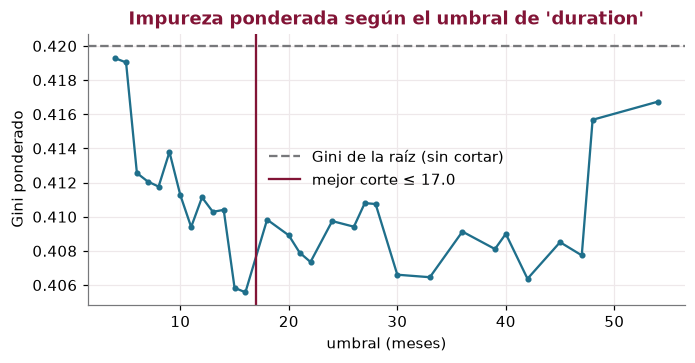

In [4]:
umbrales = np.unique(x_dur)
curva = [((x_dur <= t).sum() * gini(yg_tr.to_numpy()[x_dur <= t]) + (x_dur > t).sum() * gini(yg_tr.to_numpy()[x_dur > t])) / len(x_dur) for t in umbrales[:-1]]
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(umbrales[:-1], curva, "o-", ms=3, color=UEES["azul"])
ax.axhline(gini(yg_tr.to_numpy()), ls="--", color=UEES["gris"], label="Gini de la raíz (sin cortar)")
ax.axvline(t_dur, color=UEES["vino"], label=f"mejor corte ≤ {t_dur}")
ax.set(title="Impureza ponderada según el umbral de 'duration'", xlabel="umbral (meses)", ylabel="Gini ponderado")
ax.legend()
plt.show()

## Nivel 2 · Con scikit-learn
Un árbol de profundidad 1 (un "tocón") entrenado solo con `duration` debe elegir el mismo corte.

In [5]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

tocon = DecisionTreeClassifier(max_depth=1, random_state=SEED).fit(Xg_tr[["duration"]], yg_tr)
print(f"scikit-learn: duration ≤ {tocon.tree_.threshold[0]}")
assert np.isclose(tocon.tree_.threshold[0], t_dur), "Tu mejor corte no coincide con el de scikit-learn."
print("✓ Tu mejor corte coincide con DecisionTreeClassifier")

scikit-learn: duration ≤ 17.0
✓ Tu mejor corte coincide con DecisionTreeClassifier


### 2.1 Profundidad y sobreajuste
Para usar todas las variables necesitamos convertir las categóricas: los árboles no necesitan escalado, así que basta con un one-hot.

In [6]:
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.model_selection import cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

onehot = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), make_column_selector(dtype_include="category"))],
                           remainder="passthrough", verbose_feature_names_out=False)
filas = []
for d in (1, 2, 3, 4, 6, 8, 12, None):
    r = cross_validate(make_pipeline(onehot, DecisionTreeClassifier(max_depth=d, random_state=SEED)), Xg_tr, yg_tr, cv=cv,
                       scoring="roc_auc", return_train_score=True)
    filas.append({"max_depth": "sin límite" if d is None else d, "AUC entrenamiento": r["train_score"].mean(), "AUC validación": r["test_score"].mean()})
tabla_prof = pd.DataFrame(filas).set_index("max_depth").round(3)
tabla_prof

,AUC entrenamiento,AUC validación
max_depth,,
1,0.670,0.670
2,0.721,0.666
3,0.764,0.673
4,0.819,0.678
6,0.907,0.648
8,0.961,0.639
12,0.998,0.606
sin límite,1.000,0.601


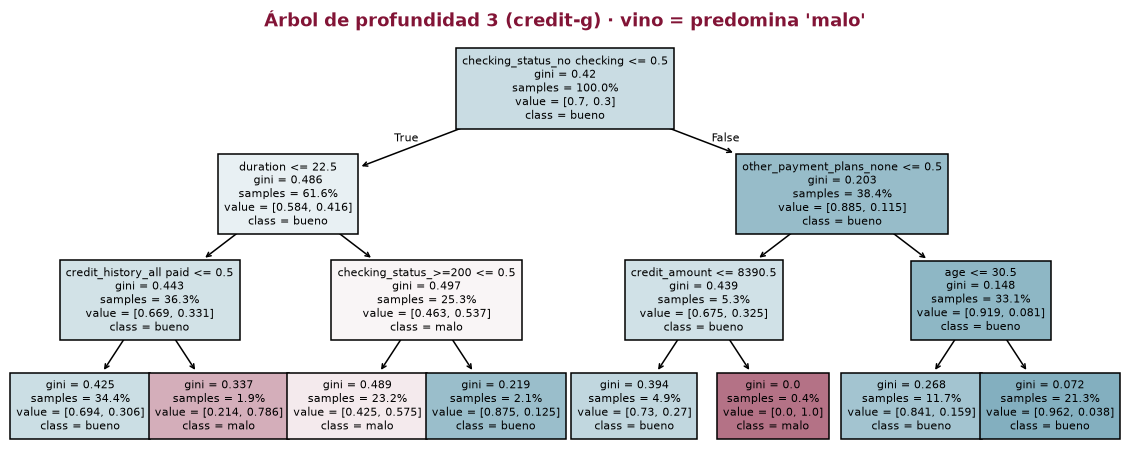

In [7]:
from matplotlib.colors import to_rgb


def color_nodo(p_malo):
    """Vino si predomina 'malo', azul si predomina 'bueno'; más intenso cuanto más puro es el nodo."""
    base = np.array(to_rgb(UEES["vino"] if p_malo >= 0.5 else UEES["azul"]))
    k = min(1.0, abs(p_malo - 0.5) * 2) * 0.6
    return tuple(1 - k * (1 - base))


arbol3 = make_pipeline(onehot, DecisionTreeClassifier(max_depth=3, random_state=SEED)).fit(Xg_tr, yg_tr)
fig, ax = plt.subplots(figsize=(13, 5))
nodos = plot_tree(arbol3[-1], feature_names=arbol3[0].get_feature_names_out(), class_names=["bueno", "malo"], filled=True,
                  impurity=True, fontsize=7, ax=ax, proportion=True)
valores = arbol3[-1].tree_.value[:, 0, :]
cajas = [a for a in nodos if a.get_bbox_patch() is not None]      # los rótulos True/False no tienen caja
for anot, v in zip(cajas, valores):            # paleta UEES en lugar de los colores por defecto
    anot.get_bbox_patch().set_facecolor(color_nodo(v[1] / v.sum()))
ax.set_title("Árbol de profundidad 3 (credit-g) · vino = predomina 'malo'")
plt.show()

**Qué observar.** El AUC de entrenamiento sube hasta 1 con la profundidad, pero el de validación toca techo muy pronto y luego cae: un árbol profundo memoriza (animación A2.6). El árbol de profundidad 3 se lee como reglas: el estado de la cuenta corriente (`checking_status`) y la duración del crédito aparecen arriba.

### 2.2 Bosque aleatorio: error OOB e importancia de variables

Exactitud OOB: 0.757 · exactitud por validación cruzada: 0.747 ± 0.017


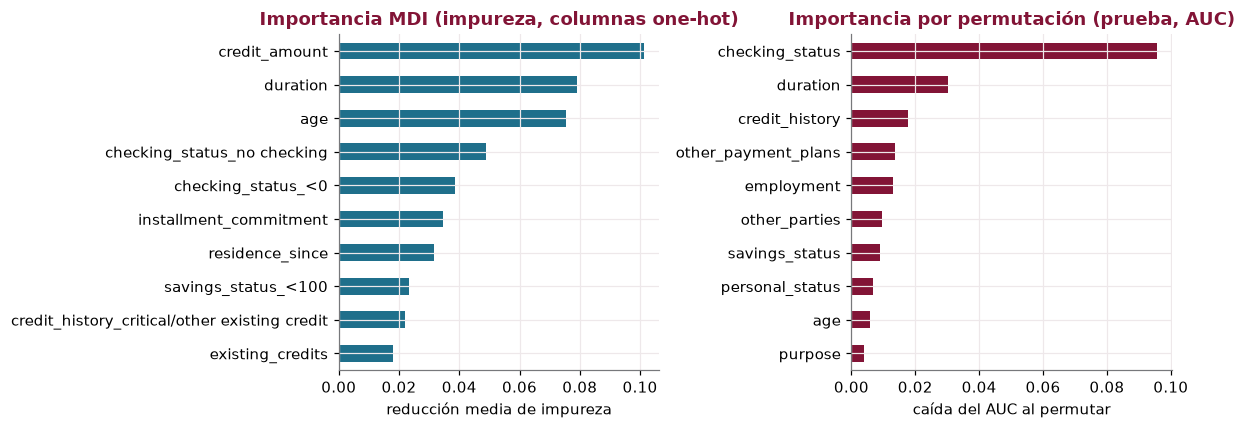

In [8]:
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.inspection import permutation_importance

bosque = make_pipeline(onehot, RandomForestClassifier(n_estimators=500, oob_score=True, random_state=SEED, n_jobs=-1)).fit(Xg_tr, yg_tr)
exact_cv = cross_validate(make_pipeline(onehot, RandomForestClassifier(n_estimators=500, random_state=SEED, n_jobs=-1)), Xg_tr, yg_tr, cv=cv, scoring="accuracy")["test_score"]
print(f"Exactitud OOB: {bosque[-1].oob_score_:.3f} · exactitud por validación cruzada: {exact_cv.mean():.3f} ± {exact_cv.std():.3f}")

nombres_oh = bosque[0].get_feature_names_out()
mdi = pd.Series(bosque[-1].feature_importances_, index=nombres_oh).sort_values(ascending=False)
perm = permutation_importance(bosque, Xg_te, yg_te, scoring="roc_auc", n_repeats=10, random_state=SEED, n_jobs=-1)
perm_s = pd.Series(perm.importances_mean, index=Xg_te.columns).sort_values(ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
mdi.head(10)[::-1].plot.barh(ax=axes[0], color=UEES["azul"])
axes[0].set(title="Importancia MDI (impureza, columnas one-hot)", xlabel="reducción media de impureza")
perm_s.head(10)[::-1].plot.barh(ax=axes[1], color=UEES["vino"])
axes[1].set(title="Importancia por permutación (prueba, AUC)", xlabel="caída del AUC al permutar")
plt.tight_layout()
plt.show()

**Qué observar.** La exactitud OOB es muy parecida a la de validación cruzada: el bosque trae su propia validación gratis (animación A2.7). La importancia **MDI** se calcula en entrenamiento y favorece a las variables con muchos valores posibles (`credit_amount`, `age`); la importancia **por permutación**, medida en datos no vistos, es más confiable para explicar el modelo.

### 2.3 Boosting como referencia

In [9]:
hgb = HistGradientBoostingClassifier(max_iter=500, learning_rate=0.05, early_stopping=True, validation_fraction=0.2,
                                     n_iter_no_change=20, categorical_features="from_dtype", random_state=SEED)
hgb.fit(Xg_tr, yg_tr)
print(f"HistGradientBoosting se detuvo en {hgb.n_iter_} etapas (parada temprana) de 500 posibles")

HistGradientBoosting se detuvo en 61 etapas (parada temprana) de 500 posibles


`HistGradientBoostingClassifier` trata las categóricas de forma nativa (`categorical_features="from_dtype"`) y detiene el entrenamiento cuando la validación interna deja de mejorar (animación A2.8).

## Nivel 3 · Laboratorio: comparar cinco modelos con MLflow

Reglas del juego (las mismas de la Tarea 2):
1. Todo el preprocesamiento dentro del pipeline.
2. Hiperparámetros elegidos con `GridSearchCV` **solo con el entrenamiento**.
3. Métrica de negocio: **costo esperado por solicitud** $\frac{5\,FN + 1\,FP}{n}$, con el umbral elegido por validación cruzada.
4. Cada modelo es una **corrida de MLflow** con sus parámetros, métricas y el modelo.

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, confusion_matrix, roc_auc_score
from sklearn.model_selection import GridSearchCV, cross_val_predict
from sklearn.svm import SVC

C_FN, C_FP = 5, 1
escalado = ColumnTransformer([("num", StandardScaler(), make_column_selector(dtype_include="number")),
                              ("cat", OneHotEncoder(handle_unknown="ignore"), make_column_selector(dtype_include="category"))])
candidatos = {
    "logistica": (make_pipeline(escalado, LogisticRegression(max_iter=3000)), {"logisticregression__C": [0.01, 0.1, 1, 10]}),
    "svm_rbf": (make_pipeline(escalado, SVC(probability=True, random_state=SEED)), {"svc__C": [0.3, 1, 3], "svc__gamma": ["scale", 0.01]}),
    "arbol": (make_pipeline(onehot, DecisionTreeClassifier(random_state=SEED)), {"decisiontreeclassifier__max_depth": [2, 3, 4, 6], "decisiontreeclassifier__min_samples_leaf": [5, 20]}),
    "bosque": (make_pipeline(onehot, RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1)), {"randomforestclassifier__max_features": ["sqrt", 0.5], "randomforestclassifier__min_samples_leaf": [1, 5]}),
    "hgb": (HistGradientBoostingClassifier(categorical_features="from_dtype", random_state=SEED), {"learning_rate": [0.03, 0.1], "max_depth": [3, None]}),
}


def costo_medio(y, p, umbral):
    tn, fp, fn, tp = confusion_matrix(y, (p >= umbral).astype(int), labels=[0, 1]).ravel()
    return (C_FN * fn + C_FP * fp) / len(y)


def umbral_por_costo(y, p):
    grilla = np.round(np.linspace(0.05, 0.9, 86), 2)
    costos = [costo_medio(y, p, t) for t in grilla]
    return float(grilla[int(np.argmin(costos))]), float(min(costos))

In [11]:
mlflow.set_tracking_uri("sqlite:///mlflow.db")          # base de datos local; se explora con: mlflow ui --backend-store-uri sqlite:///mlflow.db
mlflow.set_experiment("E2.4-credit-g")
resumen = {}
for nombre, (pipe, malla) in candidatos.items():
    with mlflow.start_run(run_name=nombre):
        # TODO: GridSearchCV con cv y scoring="roc_auc"; probabilidades fuera del fold del mejor modelo; umbral por costo.
        busq = GridSearchCV(pipe, malla, cv=cv, scoring="roc_auc", n_jobs=-1).fit(Xg_tr, yg_tr)
        p_oof = cross_val_predict(busq.best_estimator_, Xg_tr, yg_tr, cv=cv, method="predict_proba")[:, 1]
        t_opt, costo_cv = umbral_por_costo(yg_tr, p_oof)
        auc_folds = [busq.cv_results_[f"split{k}_test_score"][busq.best_index_] for k in range(cv.get_n_splits())]
        mlflow.log_params({k.split("__")[-1]: v for k, v in busq.best_params_.items()})
        mlflow.log_metrics({"auc_cv": busq.best_score_, "auc_cv_std": float(np.std(auc_folds)), "pr_auc_oof": average_precision_score(yg_tr, p_oof),
                            "umbral_costo": t_opt, "costo_cv": costo_cv})
        mlflow.set_tags({"familia": nombre, "semana": "2", "dataset": "credit-g (OpenML 31)"})
        resumen[nombre] = {"modelo": busq.best_estimator_, "umbral": t_opt}
print("Corridas registradas en MLflow:", list(resumen))

Corridas registradas en MLflow: ['logistica', 'svm_rbf', 'arbol', 'bosque', 'hgb']


In [12]:
corridas = mlflow.search_runs(experiment_names=["E2.4-credit-g"], order_by=["metrics.costo_cv ASC"])
tabla_ml = corridas[["tags.mlflow.runName", "metrics.auc_cv", "metrics.auc_cv_std", "metrics.pr_auc_oof", "metrics.umbral_costo", "metrics.costo_cv"]]
tabla_ml = tabla_ml.drop_duplicates("tags.mlflow.runName").set_index("tags.mlflow.runName").round(3)
tabla_ml.columns = ["AUC CV", "± DE", "PR-AUC OOF", "umbral por costo", "costo CV por solicitud"]
tabla_ml

,AUC CV,± DE,PR-AUC OOF,umbral por costo,costo CV por solicitud
tags.mlflow.runName,,,,,
bosque,0.796,0.019,0.616,0.17,0.512
logistica,0.782,0.024,0.592,0.14,0.523
svm_rbf,0.781,0.028,0.583,0.17,0.532
hgb,0.778,0.021,0.597,0.12,0.540
arbol,0.696,0.054,0.433,0.20,0.584


Elegimos el modelo con **menor costo en validación** (no el de mayor AUC) y lo evaluamos **una sola vez** en la prueba, junto con la regla ingenua de rechazar a todos (costo = proporción de buenos × 1) y la de aprobar a todos (proporción de malos × 5).

In [13]:
ganador = tabla_ml.index[0]
modelo_final = resumen[ganador]["modelo"].fit(Xg_tr, yg_tr)
p_te = modelo_final.predict_proba(Xg_te)[:, 1]
final = {
    f"{ganador} · umbral {resumen[ganador]['umbral']}": costo_medio(yg_te, p_te, resumen[ganador]["umbral"]),
    f"{ganador} · umbral 0.5": costo_medio(yg_te, p_te, 0.5),
    "aprobar a todos": C_FN * yg_te.mean(),
    "rechazar a todos": C_FP * (1 - yg_te.mean()),
}
print(f"AUC en prueba del ganador ({ganador}): {roc_auc_score(yg_te, p_te):.3f}")
pd.Series(final, name="costo por solicitud (prueba)").round(3)

AUC en prueba del ganador (bosque): 0.768


bosque · umbral 0.17    0.556
bosque · umbral 0.5     1.000
aprobar a todos         1.500
rechazar a todos        0.700
Name: costo por solicitud (prueba), dtype: float64

**Qué observar.** Con clases y costos desbalanceados, el umbral 0.5 es un mal punto de operación; el umbral por costo (bastante menor) reduce el costo esperado. Los modelos quedan cerca unos de otros y **las diferencias son del orden de su desviación entre folds**: por eso se reporta media ± DE y se desconfía de ganadores por milésimas. Abre la interfaz con `mlflow ui --backend-store-uri sqlite:///mlflow.db` para comparar las corridas.

## Nivel 4 · Reto: ¿cuánto miente la validación no anidada?
Si elegimos hiperparámetros con validación cruzada y reportamos ese mismo puntaje, estamos **evaluando con los datos que usamos para elegir**: el resultado es optimista. La validación anidada mete la búsqueda dentro de cada fold externo.

### 4.1 Un experimento donde conocemos la verdad
Con **ruido puro** (etiquetas al azar) el AUC real de cualquier modelo es 0.5. Buscamos C y γ de una SVM en una malla de 36 combinaciones y comparamos el "mejor de la malla" con la estimación anidada, en 5 repeticiones.

In [14]:
from sklearn.model_selection import cross_val_score

malla_svm = {"svc__C": [0.1, 0.3, 1, 3, 10, 30], "svc__gamma": [0.001, 0.01, 0.03, 0.1, 0.3, 1]}
filas = []
for rep in range(5):
    rr = np.random.default_rng(SEED + rep)
    X_r, y_r = rr.normal(size=(200, 20)), rr.integers(0, 2, 200)
    interna = StratifiedKFold(n_splits=5, shuffle=True, random_state=rep)
    externa = StratifiedKFold(n_splits=5, shuffle=True, random_state=100 + rep)
    # TODO: AUC no anidada = best_score_ de GridSearchCV; AUC anidada = cross_val_score de GridSearchCV con la CV externa.
    busq_r = GridSearchCV(make_pipeline(StandardScaler(), SVC()), malla_svm, cv=interna, scoring="roc_auc", n_jobs=-1)
    no_anidada = busq_r.fit(X_r, y_r).best_score_
    anidada = cross_val_score(busq_r, X_r, y_r, cv=externa, scoring="roc_auc").mean()
    filas.append({"repetición": rep + 1, "AUC no anidada": no_anidada, "AUC anidada": anidada, "optimismo": no_anidada - anidada})
tabla_ruido = pd.DataFrame(filas).set_index("repetición")
tabla_ruido.loc["promedio"] = tabla_ruido.mean()
tabla_ruido.round(3)

,AUC no anidada,AUC anidada,optimismo
repetición,,,
1,0.575,0.493,0.082
2,0.551,0.532,0.020
3,0.521,0.447,0.073
4,0.516,0.479,0.037
5,0.534,0.482,0.052
promedio,0.539,0.487,0.053


**Qué observar.** Sobre ruido, el "mejor de la malla" reporta un AUC claramente mayor que 0.5 en todas las repeticiones: es puro **sesgo de selección**, porque entre 36 configuraciones siempre alguna acierta por azar en esos folds. La estimación anidada se queda en torno a 0.5, que es la verdad.

### 4.2 En credit-g
Con datos reales, un modelo estable y una malla pequeña, el optimismo puede ser imperceptible. Lo medimos para la SVM del nivel 3.

In [15]:
externa = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED + 1)
pipe, malla = candidatos["svm_rbf"]
pipe = make_pipeline(escalado, SVC(random_state=SEED))                 # sin probability=True: aquí solo importa el AUC
no_anidada_g = GridSearchCV(pipe, malla, cv=cv, scoring="roc_auc", n_jobs=-1).fit(Xg_tr, yg_tr).best_score_
anidada_g = cross_val_score(GridSearchCV(pipe, malla, cv=cv, scoring="roc_auc", n_jobs=-1), Xg_tr, yg_tr, cv=externa, scoring="roc_auc")
print(f"credit-g · SVM: no anidada {no_anidada_g:.4f} · anidada {anidada_g.mean():.4f} ± {anidada_g.std():.4f} · optimismo {no_anidada_g - anidada_g.mean():+.4f}")

credit-g · SVM: no anidada 0.7814 · anidada 0.7850 ± 0.0169 · optimismo -0.0036


**Qué observar.** En credit-g la diferencia es de milésimas (puede salir incluso negativa) y mucho menor que la desviación entre folds: con 6 configuraciones y un modelo estable, el sesgo de selección se pierde en el ruido de la partición. Crece con el tamaño de la malla, con modelos más flexibles y con pocos datos, como mostró el experimento con ruido. Para un informe, reporta la estimación anidada o una prueba reservada que nunca participó en la elección.

> **Respuesta de referencia**

**Reflexión · ¿qué modelo recomendar?** Con 750 solicitudes de entrenamiento las diferencias entre regresión logística, SVM y bosque suelen ser menores que la desviación entre folds. Un criterio defendible: el modelo más simple dentro de una desviación estándar del mejor (aquí suele ser la regresión logística), porque es más fácil de explicar al comité de crédito y de auditar por sesgo (semana 4). La recomendación debe incluir el umbral y la matriz de costos que la justifican.

## Autoverificación

In [16]:
assert np.isclose(tocon.tree_.threshold[0], t_dur)
assert tabla_prof.loc["sin límite", "AUC entrenamiento"] > 0.99 > tabla_prof.loc["sin límite", "AUC validación"], "El árbol sin límite debería memorizar."
assert abs(bosque[-1].oob_score_ - exact_cv.mean()) < 0.05, "La exactitud OOB debería parecerse a la de validación cruzada."
assert len(tabla_ml) == 5, "Deberían existir 5 corridas en MLflow."
assert final[f"{ganador} · umbral {resumen[ganador]['umbral']}"] < min(final["aprobar a todos"], final["rechazar a todos"]), "El modelo debería superar a las reglas ingenuas."
assert tabla_ruido.loc["promedio", "optimismo"] > 0.03, "Sobre ruido, la validación no anidada debería ser claramente optimista."
assert abs(tabla_ruido.loc["promedio", "AUC anidada"] - 0.5) < 0.05, "Sobre ruido, la estimación anidada debería rondar 0.5."
print("✓ E2.4 completo")

✓ E2.4 completo


## Lista de cotejo (autoevaluación del laboratorio)

- [ ] Tu Gini y tu mejor corte coinciden con scikit-learn.
- [ ] Viste el sobreajuste por profundidad y leíste un árbol.
- [ ] Comparaste OOB con validación cruzada y MDI con permutación.
- [ ] Registraste 5 modelos en MLflow y elegiste por costo con umbral por validación cruzada.
- [ ] Evaluaste el ganador una sola vez en la prueba y cuantificaste el optimismo de la validación no anidada.

**Reflexión:** si dos modelos empatan dentro de su desviación estándar, ¿qué otros criterios usarías para elegir?

**Cómo te prepara para la Tarea 2:** es el mismo flujo, aplicado a la predicción de módulos de software defectuosos (jm1), con curvas de aprendizaje y calibración.

## Desafío opcional con IA agéntica · Un sexto modelo en MLflow

**Objetivo.** Sumar KNN a la comparación de credit-g y registrarlo en MLflow con las mismas reglas.

**Prompt inicial.** Úsalo en la herramienta que prefieras (Claude Code, Codex, Gemini en Colab, ChatGPT…), con este notebook resuelto como contexto. Pide primero un plan y revisa cada paso antes de aprobarlo.

```text
En el notebook resuelto E2.4 (árboles, bosques y comparación con credit-g y MLflow), agrega un sexto modelo: KNN con StandardScaler en el pipeline y búsqueda de k y de los pesos. Regístralo en el mismo experimento de MLflow (sqlite:///mlflow.db) con los mismos folds y la misma métrica de costo 5:1. Actualiza la tabla comparativa con media ± desviación y explica si cambia la elección del modelo.
```

**Cómo verificar el resultado**

- Se usan los mismos folds y la misma métrica de costo que los otros cinco modelos.
- La corrida aparece en MLflow con sus parámetros y métricas.
- La conclusión considera la variabilidad entre folds antes de declarar un ganador.

**Declara el uso de IA** (norma f del sílabo): herramienta, prompts relevantes, qué verificaste tú y qué corregiste. El desafío es opcional y no se califica; lo que cuenta es que puedas explicar cada decisión.